In [133]:
from pathfinding.core.diagonal_movement import DiagonalMovement
from pathfinding.core.grid import Grid
from pathfinding.finder.a_star import AStarFinder
import numpy as np

from RRAM import RepresentateState

### Libreria PathFinding

A simple usage example to find a path using A*.

Create a map using a 2D-list. Any value smaller or equal to 0 describes an obstacle. Any number bigger than 0 describes the weight of a field that can be walked on. The bigger the number the higher the cost to walk that field. In this example we like the algorithm to create a path from the upper left to the bottom right. To make it not to easy for the algorithm we added an obstacle in the middle, so it can not use the direct way. We ignore the weight for now, all fields have the same cost. Feel free to create a more complex map

In [134]:
matriz = [
    [0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1],
    [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1],
    [0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1],
    [1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0],
    [0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0],
    [1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1],
    [1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0],
    [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1],
    [0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1],
    [1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0],
    [0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0],
    [1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0],
    [0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0],
    [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0],
    [1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0]
]
# matriz = np.zeros((10, 10))

# # relleno la matriz con 1 en posiciones aleatorias
# for i in range(10):
#     for j in range(10):
#         matriz[i][j] = np.random.choice([0, 1])


# print(matriz)

Note: you can use negative values to describe different types of obstacles. It does not make a difference for the path finding algorithm but it might be useful for your later map evaluation.

we create a new grid from this map representation. This will create Node instances for every element of our map. It will also set the size of the map. We assume that your map is a square, so the size height is defined by the length of the outer list and the width by the length of the first list inside it.

In [135]:
grid = Grid(matrix=matriz)
(grid.height, grid.width)

# print(grid.grid_str())

(20, 20)

we get the start (top-left) and endpoint (bottom-right) from the map:

In [136]:
start = grid.node(0, 19)
end = grid.node(19, 7)

create a new instance of our finder and let it do its work. We allow diagonal movement. The find_path function does not only return you the path from the start to the end point it also returns the number of times the algorithm needed to be called until a way was found.

In [137]:
path, runs = AStarFinder(diagonal_movement=DiagonalMovement.never).find_path(start, end, grid)
print('operations:', runs, 'path length:', len(path))

operations: 71 path length: 34


thats it. We found a way. Now we can print the result (or do something else with it). Note that the start and end points are part of the path.

In [138]:
print('operations:', runs, 'path length:', len(path))

operations: 71 path length: 34


In [139]:
print(grid.grid_str(path=path, start=start, end=end))

+--------------------+
|##  #   #   #### #  |
|##    ##### #  # ## |
|##  # ### ###   ##  |
|   ## ###  ### # ###|
|# #### # ##    # ###|
|# # #     ###  # ###|
|#  #  # # # # #    #|
| #   #  # # # ##  xe|
|##### ###  # #####x |
| ### #  # # #xxxx#x#|
|##   ### #   x##xxx#|
|  #   #     #x# ####|
|#   ## #  ##xx # ## |
|#  # #### xxx     # |
| ### #  # x  # ### #|
|###  ## ##x###  # ##|
| # #xxxxxxx#  ##   #|
|#xxxx#  # #  ###  ##|
|xx   ##### #  ### ##|
|s  ####  ### ##    #|
+--------------------+


you can also print the path as tuple of x and y coordinates:

In [140]:
path

[<GridNode(0:19 0x1d2f0205990)>,
 <GridNode(0:18 0x1d2f02bb890)>,
 <GridNode(1:18 0x1d2f02bb2d0)>,
 <GridNode(1:17 0x1d2f02bb790)>,
 <GridNode(2:17 0x1d2f02bb710)>,
 <GridNode(3:17 0x1d2f02bbfd0)>,
 <GridNode(4:17 0x1d2f02baf10)>,
 <GridNode(4:16 0x1d2f01e6f90)>,
 <GridNode(5:16 0x1d2f01e5150)>,
 <GridNode(6:16 0x1d2f01e4150)>,
 <GridNode(7:16 0x1d2f01e6a90)>,
 <GridNode(8:16 0x1d2f01e4fd0)>,
 <GridNode(9:16 0x1d2f01e5f50)>,
 <GridNode(10:16 0x1d2f01e7110)>,
 <GridNode(10:15 0x1d2f01e5950)>,
 <GridNode(10:14 0x1d2f01d6250)>,
 <GridNode(10:13 0x1d2f013af50)>,
 <GridNode(11:13 0x1d2f013bb10)>,
 <GridNode(12:13 0x1d2f013a510)>,
 <GridNode(12:12 0x1d2f00bb5d0)>,
 <GridNode(13:12 0x1d2f00bb4d0)>,
 <GridNode(13:11 0x1d2f0201f10)>,
 <GridNode(13:10 0x1d2f0202a90)>,
 <GridNode(13:9 0x1d2f0201a90)>,
 <GridNode(14:9 0x1d2f0202750)>,
 <GridNode(15:9 0x1d2f0202310)>,
 <GridNode(16:9 0x1d2f0203590)>,
 <GridNode(16:10 0x1d2f0200110)>,
 <GridNode(17:10 0x1d2f02004d0)>,
 <GridNode(18:10 0x1d2f02038d0)

In [141]:
# Quiero representar el camino en la matriz primero paso los elementos del path a una lista
path = list(path)
# Luego recorro la lista y en la matriz coloco un 2 en las posiciones que me indica el path
for i in range(len(path)):
    matriz[path[i][0]][path[i][1]] = 2

print(matriz)

TypeError: 'GridNode' object is not subscriptable

### Mi PathFinding

In [ ]:
# Compruebo primero si hay caminables en la primera y última columna de la matriz
def is_path(configuration_matrix: np.ndarray) -> bool:

    # obtengo las dimensiones de la matriz
    Ejex, Ejey = configuration_matrix.shape

    # Creo una variable para saber si hay camino
    ExistPath = False

    # Creo el grid a partir de la matriz de configuración
    grid = Grid(matrix=configuration_matrix)

    # Compruebo si hay trampas en la primera y última columna
    if 1 in configuration_matrix[:, 0] and 1 in configuration_matrix[:, -1]:
        # obtengo las posiciones de los 1 en la primera columna
        start = np.where(configuration_matrix[:, 0] == 1)[0]

        # Creo la lista de nodos de inicio sabiendo que todos los nodos de inicio están en la primera columna
        start = [(i, 0) for i in start]

        # obtengo las posiciones de los 1 en la última columna
        end = np.where(configuration_matrix[:, -1] == 1)[0]

        # Creo la lista de nodos de fin sabiendo que todos los nodos de fin están en la última columna en forma de grid node
        end = [(i, Ejey - 1) for i in end]

        # Recorro los nodos de inicio y fin para ver si hay camino
        for i in start:
            for j in end:
                start = grid.node(i[0], i[1])
                end = grid.node(j[0], j[1])

                print(start)
                print(end)

                path = AStarFinder(diagonal_movement=DiagonalMovement.never).find_path(start, end, grid)
                if len(path) > 0:
                    ExistPath = True
                    break
            if len(path) > 0:
                break
        # print(grid.grid_str(path=path, start=start, end=end))
        return ExistPath
    else:
        return ExistPath

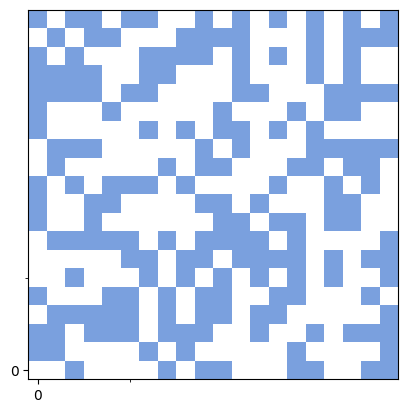

In [ ]:
Ejex = 20
Ejey = 20

matriz = np.zeros((Ejex, Ejey))

# relleno la matriz con 1 en posiciones aleatorias
for i in range(Ejex):
    for j in range(Ejey):
        matriz[i][j] = np.random.choice([0, 1])

RepresentateState(matriz, "prueba.png")

In [ ]:

# Imprimo un salto de linea

if is_path(matriz):
    print('Hay camino')
else:
    print('No hay camino')

<GridNode(1:0 0x1d2f00bb4d0)>
<GridNode(0:19 0x1d2f00bb5d0)>
Hay camino
